## TSB-AD Quick Start

### Run AD Model

In this tutorial, we demonstrate how to (i) load a univariate or multivariate time series from the TSB-AD benchmark, (ii) run an unsupervised anomaly detector, and (iii) evaluate its detection quality using standard measures.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
import pandas as pd
from TSB_AD.model_wrapper import run_Unsupervise_AD, run_Semisupervise_AD
from TSB_AD.evaluation.metrics import get_metrics

# Specify data directory (single univariate/ multivariate file)
data_direc = './Datasets/TSB-AD-U/001_NAB_id_1_Facility_tr_1007_1st_2014.csv'

# Loading Data
df = pd.read_csv(data_direc).dropna()
data = df.iloc[:, 0:-1].values.astype(float)
label = df['Label'].astype(int).to_numpy()

print("Loaded data with shape:", data.shape)
print("Loaded labels with shape:", label.shape)

# model output
output_model = run_Unsupervise_AD('Sub_PCA', data)

Loaded data with shape: (4031, 1)
Loaded labels with shape: (4031,)


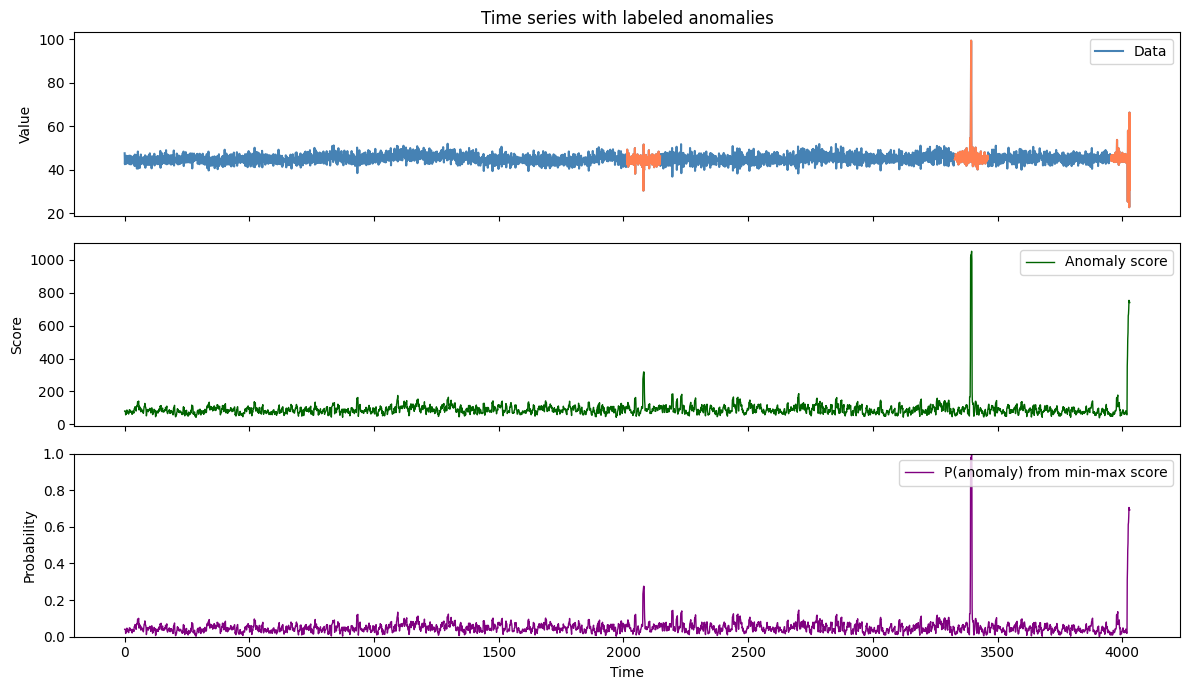

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from TSB_AD.evaluation.basic_metrics import basic_metricor

grader = basic_metricor()
range_anomaly = grader.range_convers_new(label)

series = np.asarray(data).squeeze()
if series.ndim > 1:
    series_plot = series[:, 0]
else:
    series_plot = series

score = np.asarray(output_model, dtype=float).ravel()
n = min(len(series_plot), len(score))
t = np.arange(n)
score = score[:n]
series_plot = series_plot[:n]

# Pseudo-probability from raw score (same min-max as metric_ECE with from_raw_score=True)
lo, hi = float(np.min(score)), float(np.max(score))
if hi - lo <= grader.eps:
    prob = np.full_like(score, 0.5)
else:
    prob = (score - lo) / (hi - lo)
prob = np.clip(prob, 0.0, 1.0)

fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
ax0.plot(t, series_plot, color="steelblue", linewidth=1.5, label="Data")
for r in range_anomaly:
    if r[0] >= n:
        continue
    if r[0] == r[1]:
        ax0.plot(r[0], series_plot[r[0]], "ro", markersize=8)
    else:
        ax0.plot(
            np.arange(r[0], min(r[1] + 1, n)),
            series_plot[r[0] : min(r[1] + 1, n)],
            color="coral",
            linewidth=1.5,
        )
ax0.set_ylabel("Value")
ax0.legend(loc="upper right")
ax0.set_title("Time series with labeled anomalies")

ax1.plot(t, score, color="darkgreen", linewidth=1.0, label="Anomaly score")
ax1.set_ylabel("Score")
ax1.legend(loc="upper right")

ax2.plot(t, prob, color="purple", linewidth=1.0, label="P(anomaly) from min-max score")
ax2.set_ylabel("Probability")
ax2.set_ylim(0.0, 1.0)
ax2.set_xlabel("Time")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Rejection curve: rejection rate = fraction of timesteps abstained on.
# Points are rejected in order of highest uncertainty min(p, 1-p); on the
# remaining timesteps, predictions are (p > 0.5) and F1 uses basic_metricor.metric_PointF1.
# Requires `grader`, `label`, `n`, `prob` from the cell above.

label_eval = np.asarray(label).astype(int).ravel()[:n]
p = np.asarray(prob, dtype=float).ravel()

uncertainty = np.minimum(p, 1.0 - p)
reject_order = np.argsort(-uncertainty)

n_pts = int(p.size)
rhos, f1s = [], []
for k in range(0, n_pts + 1):
    rhos.append(k / n_pts if n_pts else 1.0)
    if k >= n_pts:
        f1s.append(np.nan)
        continue
    keep = reject_order[k:]
    y = label_eval[keep]
    pr = p[keep]
    preds = (pr > 0.5).astype(int)
    f1s.append(grader.metric_PointF1(y, pr, preds=preds))

rhos_arr = np.asarray(rhos, dtype=float)
f1s_arr = np.asarray(f1s, dtype=float)
mask = np.isfinite(f1s_arr)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rhos_arr[mask], f1s_arr[mask], color="teal", linewidth=1.5)
ax.set_xlabel("Rejection rate")
ax.set_ylabel("F1 (PointF1)")
ax.set_title("Rejection curve: F1 vs. fraction rejected (uncertainty-ordered)")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


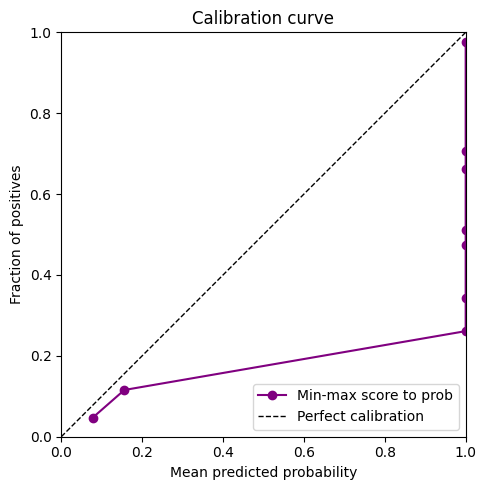

In [ ]:

from sklearn.calibration import calibration_curve

prob_mean, frac_pos = calibration_curve(label, prob, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_mean, frac_pos, "o-", color="purple", label="Min-max score to prob")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curve")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()